## Learning Objectives  
- Explore intra-category structure: do descriptions form meaningful subgroups?
- Practice clustering/visualization on one category to judge label quality.
- Use TSNE and DBSCAN to spot subclusters and potential label noise.
- Sample texts from regions/clusters to interpret what the model is seeing.

## Dataset Case Study: My CHI My Future (MCMF) Programs in Chicago

<p style="display: flex; justify-content: center; align-items: center;">
    <img src="images/cropped-cropped-Final-Logo-1.png" alt="MCDC Logo" style="width: 20%; height: auto; margin-right: 2%;">
    <img src="images/mcmf_logo.png" alt="MCMF Logo" style="width: 20%; height: auto;">
</p>

This case study explores real-world data from the My CHI My Future (MCMF) youth programs in Chicago. The dataset was selected for the [MCDC](https://sites.northwestern.edu/mcdc/) practicum course (Spring 2023, Dr. Lizhen Shi) in partnership with [My CHI My Future](https://explore.mychimyfuture.org/) and community leader Stender Von Oehsen. The project aimed to address real community needs through data science, with results featured on the [MCDC Past Projects website](https://sites.northwestern.edu/mcdc/projects/).

**Context:**

- The MCMF initiative, led by the City of Chicago, connects youth to thousands of out-of-school programs, events, and resources across the city.
- The dataset includes detailed information about program names, descriptions, categories, dates, and locations, providing a rich resource for text analysis and feature engineering.
- Students worked with community partners to clean, analyze, and model this data, supporting efforts to improve youth engagement and access to opportunities.

This notebook demonstrates how to preprocess and analyze text data from a real civic dataset, preparing it for downstream modeling and actionable insights. This lesson was co-developed by **Dr. Lizhen Shi** and **Dr. Arend Kuyper** for the MCDC pathway courses (Summer 2025). 

## Overview  
This notebook zooms into a single category from the cleaned dataset to check how consistent the descriptions are. We cluster within one label, visualize in 2D, and read sample texts to judge quality.

In [1]:
import pandas as pd
import numpy as np

### Load the cleaned dataset
Bring in `datasets/data_cleaned_20250826.csv` from the preprocessing notebook so we work on already-cleaned text fields.

In [2]:
df = pd.read_csv('datasets/data_cleaned_20250826.csv', low_memory=False)
df = df[df['Description_Clean'].str.len() > 25]
df['program_name'] = df['Program Name']
df['category_name'] = df['Category Name']
df['description'] = df['Description_Clean']
df = df[['program_name', 'category_name', 'description']].reset_index(drop=True)
df.head()

,program_name,category_name,description
0,Homework Help: Virtual Teacher in the Library,Music & Art.,get homework help certified teacher library re...
1,Art of Storytelling Learning Circle,Academic Support,makes good story developed pixar storys struct...
2,Learn American Sign Language,Academic Support,want brush american thurgood marshall branch w...
3,Learn American Sign Language,Academic Support,want brush american thurgood marshall branch w...
4,The Harold Washington Experience: Historians R...,Academic Support,april harold washington history becoming chica...


### Check category sizes
Scan counts to decide which category to inspect; start with a large one for clearer structure.

In [3]:
df.groupby('category_name').size().sort_values(ascending=False)

category_name
Sports + Wellness.          121319
Music & Art.                105638
Reading & Writing.           34535
Academic Support             13002
Science                       9442
Computers.                    9295
Building & Fixing Things      6616
Helping Your Community.       3170
Performance.                  2618
Nature.                       2569
Managing Money.               2177
Healthcare                    2154
Food.                         1711
Work + Career                 1665
Digital Media.                1556
Social Studies                 499
Teaching                       167
Customer/Human Service          91
Math                            60
Law                             48
Transportation                  24
dtype: int64

### Inspect description length
Length distribution hints at how much text we can rely on and informs any truncation choices.

<Axes: >

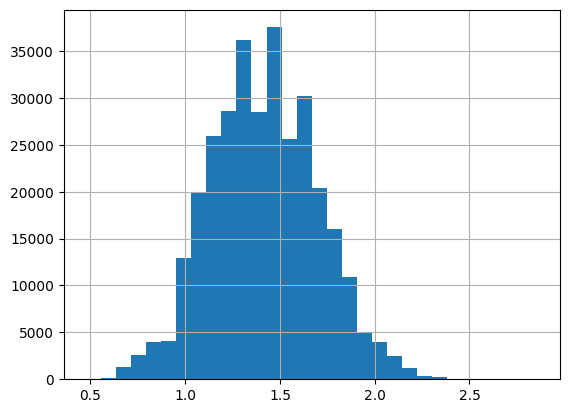

In [4]:
df['description'].map(lambda s: np.log10(len(s.split()))).hist(bins=30)

In [5]:
df.loc[251513]['description']

'everyone gets crafty creative funfilled dabble kinds art material paper art clay projects wednesday'

### Peek at sample descriptions
Read a handful of truncated descriptions to understand tone and remaining noise.

In [6]:
def f(s):
    s=s.split()
    return " ".join(s[:30])
with pd.option_context('display.max_colwidth', None):
    display(df['description'].apply(f).to_frame().sample(10))

,description
301949,basketball league playoffs championship games mount greenwood monday
190610,fornbspbook apptit mayfair branchs cookbook pick favorite cookbook recipe share groupaccessibility interpretation accommodations
123747,every summer staff campers look forward reconnecting safe engaging inclusive activitiesthe summer include sports arts fitness outdoor traditionally offered brain play environmental awareness civic engagement journaling inclusion building woven throughout
207320,universidad popular offers interactive english pleasant environment fill job applications prepare interview introduce answer greetings express writing getting know communityuniversidad popular ofrece clases ingls interactivas ambiente agradable donde aprender llenar
11566,assistive resources talking book booknbspclub discuss happiness projectnbspauthors personal reflections monthly plan improve quality life end one analyzes missteps challenges successes reaching goals shares often unexpected lessons learnedhow attendthis takes
97647,welcome legler regional maker labnbspdrop shop hours use equipment sewing machines printer laser cutter cricut electronic cutter heat press transfer machine work project librarian upcoming maker lab would rather oneonone
244073,artist maya basics ceramics together well explore handbuilding techniques pinching slab building coiling create airdry clay planters adorned animal features youll even get take home small plant live newly created
256118,offers chance explore world dinosaurs making dinomite crafts new friends focus different dinosaur
184833,short stories singing craft toddlers caregiversacompanos leer historias cantar canciones hacer una manualidad para nios meses edad sus cuidadores attendthis takes place person masks strongly encouraged cpl locations start library
71772,interested use computer refresher offering oneonone basic computer development resource digital prefer use laptop feel bring book appointment drop desk floor techrelated questions computer stop branch interpretation accommodations


### Focus on one category
Filter to a single label (here `Academic Support`) to study within-category consistency. Swap this value to audit other categories.

In [8]:
category_name = 'Academic Support'
df = df[df['category_name'] == category_name]
df.shape


(13002, 3)

In [9]:
description_cutoff = 30

Truncate descriptions to the first 30 tokens to keep embeddings fast and comparable.

### Create embeddings
Generate dense vectors for each filtered description using `fastembed.TextEmbedding`.

In [10]:
 

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans
import numpy as np
from fastembed import TextEmbedding

embedding_model = TextEmbedding()

embedding_matrix = list(embedding_model.embed(df['description'].map(lambda s: " ".join(s.split()[:description_cutoff]))))


In [11]:
embedding_matrix = np.array(embedding_matrix)
embedding_matrix.shape

(13002, 384)

### Choose `k` with an elbow plot
Use inertia across k values to pick a reasonable cluster count before visualizing.

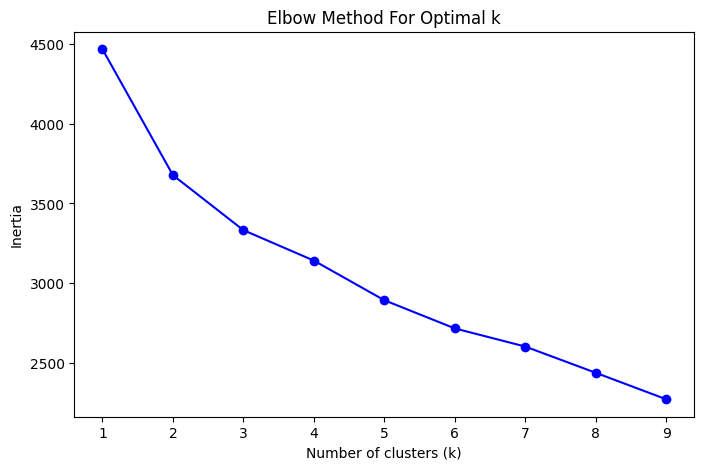

In [16]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Elbow method
inertias = []
K = range(1, 10)  # test k values from 2 to 14

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(embedding_matrix)
    inertias.append(km.inertia_)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(K, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()


### Cluster within the category
Run KMeans at the chosen k and reduce dimensions with SVD for a quick 2D view.

Shape of TF-IDF matrix: (13002, 384)


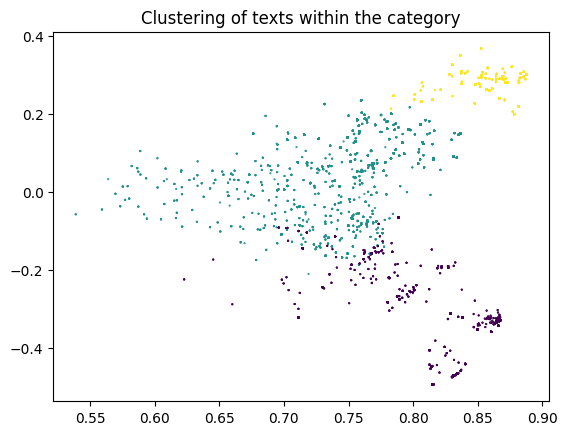

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

# Suppose you already have:
# tfidf_matrix = vectorizer.fit_transform(docs)

# 1. Look at basic info
print("Shape of TF-IDF matrix:", embedding_matrix.shape)  # (num_docs, num_terms)

# 2. Cluster the docs
n_clusters = 3  # you can adjust or use silhouette score to find a good k
km = KMeans(n_clusters=n_clusters, random_state=42)
clusters = km.fit_predict(embedding_matrix)


# 3. Dimensionality reduction for visualization
svd = TruncatedSVD(n_components=2, random_state=42)
reduced = svd.fit_transform(embedding_matrix)

plt.scatter(reduced[:, 0], reduced[:, 1], c=clusters, cmap="viridis", s=0.3)
plt.title("Clustering of texts within the category")
plt.show()
 

### Visualize with TSNE
Project embeddings with TSNE to check nonlinear structure and cluster separation.

In [20]:
from openTSNE import TSNE

embedding = TSNE(n_jobs=-1).fit(embedding_matrix)
embedding.shape

(13002, 2)

Color TSNE by KMeans labels to see how clusters map in 2D.

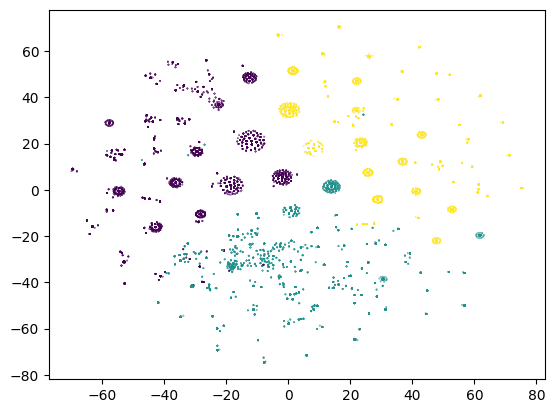

In [ ]:
plt.scatter(embedding[:, 0], embedding[:, 1], c=clusters, cmap="viridis", s=0.1)    

### DBSCAN on TSNE space
Run density-based clustering on the TSNE embedding to spot fine-grained groupings or noise points.

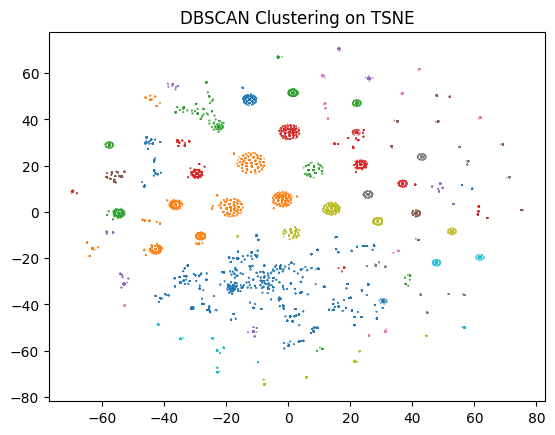

In [23]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=5, min_samples=10)
tsne_clusters = dbscan.fit_predict(embedding)

plt.scatter(embedding[:, 0], embedding[:, 1], c=tsne_clusters, cmap="tab10", s=0.1)
plt.title("DBSCAN Clustering on TSNE")
plt.show()

In [24]:
tsne_clusters

array([0, 0, 0, ..., 0, 0, 0], shape=(13002,))

### Attach cluster labels back to the data
Store KMeans clusters, TSNE coordinates, and DBSCAN clusters for inspection.

In [25]:
df['cluster'] = clusters
df['dim_0'] = reduced[:, 0]
df['dim_1'] = reduced[:, 1]
df['tsne_0'] = embedding[:, 0]
df['tsne_1'] = embedding[:, 1]
df['tsne_clusters'] = tsne_clusters
df['cluster'].value_counts()

cluster
0    4504
1    4495
2    4003
Name: count, dtype: int64

Check how many points fall into each DBSCAN cluster; lots of -1 values can indicate noise or overly strict eps/min_samples.

In [26]:
df['tsne_clusters'].value_counts()

tsne_clusters
0     1877
17     557
10     486
2      449
18     380
      ... 
37      27
55      26
87      24
57      24
74      21
Name: count, Length: 89, dtype: int64

### Read sample texts by region
Sample descriptions from different SVD dimensions to interpret what the components capture.

In [15]:
with pd.option_context('display.max_colwidth', None):
    display(df[  (df['dim_1'] > 0.1)].sample(5))
    display(df[  (df['dim_1'] <0)].sample(5))

,program_name,category_name,description,cluster,dim_0,dim_1
12040,English Classes for Intermediate Levels/Clases de InglÃ©s de Nivel Intermedio,Academic Support,english led erie house tutor popular library harold washington library study intermediatelevel english librarys english study resources celled held six thursdays september october stthursday pmthursday thursday thursday thursday thursday pmerie house modern social nonprofit programming resources mental health wellness adult education training legal moreson invitados tomar clases ingls dirigidas por maestro erie house popular library primer piso biblioteca harold washington cada clase aprender ingls intermedio cmo utilizar recursos tales como celledlas clases llevarn acabo seis jueves del septiembre octubre erie house una organizacin comunitaria sin fines lucro comprometida con bienestar las familias provee programas para nios jvenes adultos familias ofrece recursos sobre salud mental bienestar comunitario educacin entrenamiento para adultos servicios legales interpretation accommodations,1,0.763937,0.185304
29898,ESL - English Language Conversation Practice,Academic Support,improve ability communicate english new english speakers minutes english conversation different topics discussed necessary adult english learners welcome whenever interpretation accommodations,1,0.830147,0.325774
300357,French Conversation Tuesdays,Academic Support,anyone seeking practice french welcome beginning level french conversation group tuesdays fall kindly recommend basic level proficiency study method place mango languages duolingo babbel etc joining questions reach allonsyno interpretation accommodations,1,0.809509,0.184055
73938,English as a Second Language (ESL) Class,Academic Support,want english languages welcomethis help talk supervisors childrens teachers neighbors doctors esl taught small groups include speaking writing listening conversation vocabulary grammar cultural understanding every monday wednesday april june encouraged every clase ayudar hablar con sus supervisores los maestros sus hijos vecinos mdicos las clases esl imparten grupos pequeos incluyen hablar escribir escuchar conversar vocabulario gramtica comprensin cultural este curso ofrece cada lunes mircoles abril junio alienta los participantes venir todas las sesiones los participantes deben registrarse recomendamos venir cada sesin regstrese lnea enve partnership literacy chicagoaccessibilityneed interpretation accommodations summergap,1,0.869649,0.287907
147875,English as Second Language (ESL) Workshop,Academic Support,want englishthis help talking supervisors childrens teachers neighbors doctors esl taught small groups include speaking writing listening conversation vocabulary grammar cultural understanding offered every tuesday thursday ending june encouraged every drop ins welcome quieres aprender ingls esta clase ayudar hablar con sus supervisores los maestros sus hijos vecinos mdicos las clases esl imparten grupos pequeos incluy hablar escribir escuchar conversar vocabulario gramtica comprensin cultural este curso ofrece todos los martes jueves finaliza junio anima los participantes asistir todas las sesiones pero aceptan visitas sin cita previa takes place person masks strongly encouraged cpl locations questions visiting library check library faqs interpretation accommodations eventcmo asistir aeste evento lleva cabo persona recomienda encarecidamente utilizar mscaras todas las ubicaciones cpl preguntas sobre visitar biblioteca consulte nuestras preguntas frecuentes sobre uso bibliotecaaccesibilidadnecesita interpretacin del lenguaje seas otra asistencia accesibilidad para este evento por favor llame enve correo electrnico accesschipubliborg para solicitar alojamiento las solicitudes deben hacerse menos das hbiles antes del evento,1,0.858980,0.259385


,program_name,category_name,description,cluster,dim_0,dim_1
277161,Kiddie College at Euclid,Academic Support,recreational based preschoollike provides unique enjoyable experience child play peers creative atmosphere fosters process play circle crafts games storytime music fitness elements tuesday thursday,0,0.840302,-0.440551
5123,Park Kids - Winter at Lake Shore,Academic Support,safe grammar age providing variety sports dance arts crafts homework music,0,0.788674,-0.064660
100893,Kiddie College at Revere,Academic Support,visit park district website view availability recreational based preschoollike provides unique enjoyable experience child play peers creative atmosphere fosters process play circle crafts games storytime music fitness elements,0,0.814163,-0.446012
253284,"Moms, Pops & Tots Interaction at Hale",Academic Support,visit park district website view availability provides opportunity parents caregivers play interact together infants toddlers help develop motor social hands discovery approach excite world surrounds enjoy arts crafts storytelling parachute play music movement plus variety parentassisted environment,0,0.828841,-0.311667
176899,Tiny Talkers - Spanish at Eugene Field,Academic Support,spanish intended ages old interactive introduces culturallyrich immersive environment wednesday,0,0.723240,-0.134214


### Read sample texts by DBSCAN cluster
Pull example descriptions per TSNE/DBSCAN cluster to label them qualitatively and spot misfits.

In [29]:
with pd.option_context('display.max_colwidth', None):
    display(df[df['tsne_clusters']==2].sample(5))
    display(df[df['tsne_clusters']==10].sample(5))
    display(df[df['tsne_clusters']==18].sample(5))

,program_name,category_name,description,cluster,dim_0,dim_1,tsne_0,tsne_1,tsne_clusters
148487,Clases de InglÃ©s - English as a Second Language Classes,Academic Support,quieres aprender ingls este curso reune dos veces por semana ayudare hablar con sus supervisores maestros sus hijos vecinos mdicos mes curso ingls imparta grupos pequeos incluye hablar escribir escuchar conversar vocabulario grametica comprensin cultural este curso llevara acabo cada martes jueves empezando septiembre want english twiceaweek help talking supervisors childrens teachers neighbors doctors taught small groups include speaking writing listening conversation vocabulary grammar cultural understanding meets every tuesday thursday starting september space limited encouraged every accesibilidadnecesita interpretacion del lenguaje seas otra asistencia accesibilidad para este evento por favor llame enve correo electrnico accesschipubliborg para solicitar alojamiento las solicitudes deben hacerse menos dias hebiles antes del eventoaccessibilityneed interpretation accommodations,1,0.786528,0.108363,21.394065,-48.993367,2
146660,English as Second Language (ESL) Workshop,Academic Support,quieres aprender ingls esta clase ayudar hablar con sus supervisores los maestros sus hijos vecinos mdicos las clases esl imparten grupos pequeos incluyen hablar escribir escuchar conversar vocabulario gramtica comprensin cultural este curso ofrece todos los martes jueves terminando junio anima los participantes asistir todas las sesiones pero aceptan visitas sin cita previaaccesibilidadnecesita interpretacin del lenguaje seas otra asistencia accesibilidad para este evento por favor llame enve correo electrnico accesschipubliborg para solicitar alojamiento las solicitudes deben hacerse menos das hbiles antes del eventowant englishthis help talking supervisors childrens teachers neighbors doctors esl taught small groups include speaking writing listening conversation vocabulary grammar cultural understanding offered every tuesday thursday ending june encouraged every drop ins welcomenbspaccessibilityneed interpretation accommodations,1,0.805750,0.173331,30.499641,-38.871356,2
141719,Afternoon Spanish Conversation Group: Grupo de conversacin en espaol por la tarde,Academic Support,beginners native speakers welcome come enjoy speaking spanish communityled presented partnership blackstone branch library find topic discussed programnote new bring share vocabulary words grammar learned preparing conversation build along note print copies library youd like log print copies everyone copies necessaryhow takes place person masks strongly encouraged cpl locations questions visiting library check library faqs interpretation accommodations,1,0.836880,0.150682,14.441738,-39.805266,2
139787,Spanish Conversation Group,Academic Support,anyone seeking practice spanish isnbspwelcome communityled programnbspwe kindly recommend basic level ofnbspproficiency study method place joiningnbspif questions reach nos vemosaccessibilityneed interpretation accommodations summergap,1,0.805363,0.083182,23.709752,-33.950547,2
298496,Spanish Conversation Circle,Academic Support,want practice speaking spanish pullman branch spanish conversation circle conversation prompts also answer questions mango languages librarys languagelearning software experience necessary interpretation accommodations,1,0.791860,0.148570,19.154873,-31.196122,2


,program_name,category_name,description,cluster,dim_0,dim_1,tsne_0,tsne_1,tsne_clusters
312875,Kiddie College at Mann,Academic Support,recreational based preschoollike provides unique enjoyable experience child play peers creative atmosphere fosters process play circle crafts games storytime music fitness elements,0,0.815027,-0.492646,-16.547065,0.591554,10
149942,Kiddie College at Independence,Academic Support,recreational based preschoollike provides unique enjoyable experience child play peers creative atmosphere fosters process play circle crafts games storytime music fitness elements,0,0.815027,-0.492646,-18.914303,3.360868,10
67300,Kiddie College at Haas,Academic Support,recreational based preschoollike provides unique enjoyable experience child play peers creative atmosphere fosters process play circle crafts games storytime music fitness elements,0,0.815027,-0.492646,-21.657399,3.968449,10
233126,Kiddie College at Shabbona,Academic Support,recreational based preschoollike provides unique enjoyable experience child play peers creative atmosphere fosters process play circle crafts games storytime music fitness elements,0,0.815027,-0.492646,-18.914303,3.360868,10
4299,Kiddie College - Spring at Maggie Daley,Academic Support,recreational based preschoollike provides unique enjoyable experience child play peers creative atmosphere fosters process play circle crafts games storytime music fitness elements,0,0.815027,-0.492646,-18.615950,1.940395,10


,program_name,category_name,description,cluster,dim_0,dim_1,tsne_0,tsne_1,tsne_clusters
223624,Play School at Merrimac,Academic Support,play provides opportunity socialization interaction peers group variety help develop motor social playful setting play like music games creative crafts help enhance childs experience away parents dunning tuesday thursday,0,0.865618,-0.321279,-24.665275,36.718322,18
235144,Play School at West Lawn,Academic Support,play provides opportunity socialization interaction peers group variety help develop motor social playful setting play like music games creative crafts help enhance childs experience away parents tuesday thursday,0,0.865262,-0.327116,-22.512500,36.567611,18
252609,Play School at Norwood,Academic Support,play provides opportunity socialization interaction peers group variety help develop motor social playful setting play like music games creative crafts help enhance childs experience away parents norwood park monday wednesday,0,0.858358,-0.325195,-27.379856,44.572908,18
59965,Play School at Sheil,Academic Support,play provides opportunity socialization interaction peers group variety help develop motor social playful setting friday,0,0.847710,-0.278294,-24.274429,48.556631,18
35367,Play School at Addams,Academic Support,play provides opportunity socialization interaction peers group variety help develop motor social playful setting play like music games creative crafts help enhance childs experience away parents saturday,0,0.865952,-0.342462,-25.524012,50.012863,18


## Wrap-up
You inspected substructure within a single category using embeddings, KMeans, TSNE, and DBSCAN, then read sample texts to interpret clusters. Repeat this for other categories to flag noisy labels, merge overlapping subtopics, or tune clustering parameters (k, eps, min_samples, token cutoff).